# Parameter estimation and regularisation

This notebook is some experimentation with parameter estimation and regularisation after reading Chapter 8 of Mathematics for Machine Learning.

Adding a regularisation term to a loss function pertains to functional models. 

To relate this to the probabilistic setting, a regularisation term added to a loss function (of a functional model) is analogous to using MAP, where we place a prior distribution on the parameters (which favours parameters with a higher probability of occurring).

This notebook plays around with parameter estimation and regularisation for functional (aka. function based) models. 

Specifically:

- We generate some data (with added Gaussian noise to introduce some randomness). The output will be based on a linear polynomial in the inputs (which we will know, but the model will not).

- Purposely overfit using an overly rich model space (polynomials up to a relatively large degree).


- Then we will regularise.

- The regularisation (hyper)parameter, $\lambda$, will need to be tuned. We will achieve this by splitting our training data into training and validation data. For each choice of hyperparameter, $\lambda$, the training data will optimise the parameters/polynomial coefficients ($\underline{\theta}$, say) with respect to the chosen $\lambda$. Then, the validation data will be used to tune the hyperparameter (i.e., choose the $\lambda$ whose corresponding parameters $\underline{\theta}$ perform best.)

## Generating data

We create 10 data points given by $y = 5x + 3 + \varepsilon$, where $\varepsilon \sim \mathcal{N}(0,3^2)$. 

We will split the data into 5 training values, and 5 validation values. (We do not bother with test values here, as we can test with our eyes whether the model is good or not by looking at a plot...)

With 5 training values, a model space of polynomials of degree 4 can perfectly fit the points (cf. [Polynomial interpolation](https://en.wikipedia.org/wiki/Polynomial_interpolation)). This will nicely show us the overfitting in play.

In [223]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from collections import defaultdict

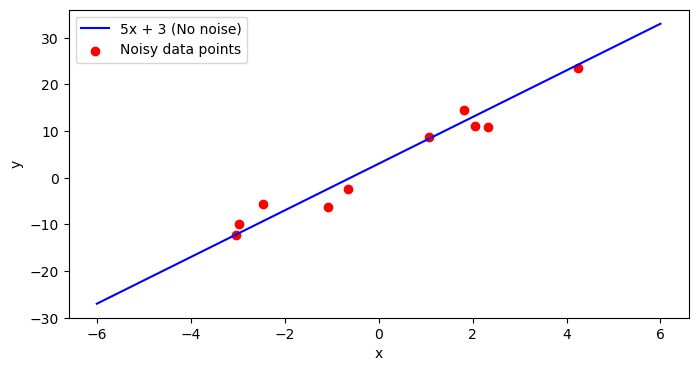

In [224]:
def noisy_function(x,noise=0):
    return 5*x + 3 + noise
    
#generate x-values between -5 and 5, also generate noise
amt_of_data_pts = 10
x_array = [(np.random.random()-0.5)*10 for _ in range(amt_of_data_pts)]
noise_array = np.random.normal(loc=0, scale=3, size=amt_of_data_pts)
y_values = [noisy_function(x,noise) for (x,noise) in zip(x_array,noise_array)]

#plot the data-generating polynomial (with no noise), as well as the data points (with noise).

x_many_pts = np.linspace(-6,6, 200)
y_no_noise = noisy_function(x_many_pts)  # no noise (default argument to this function is `noise = 0`)

plt.figure(figsize=(8,4))
plt.plot(x_many_pts, y_no_noise, label='5x + 3 (No noise)', color='blue')
plt.scatter(x_array, y_values, label='Noisy data points', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper left')
plt.show()

### Splitting the data up 

We split our 10 points into 5 training points and 5 validation points. 

The 5 training points will be used to find parameters (coefficients of the polynomial). Whenever we introduce regularisation (e.g., $\lambda||\theta||^2$), the validation set will be used to tune the hyperparameter $\lambda$.

As our x-values are generated randomly within the valid interval, that is, there is no ordering on the list of values in `x_array`, taking the first 5 values as our training data and last 5 values as validation data is as good as any other choice. 

In [226]:
x_train = np.asarray(x_array[:5])
x_validate = np.asarray(x_array[5:])

y_train = np.asarray(y_values[:5])
y_validate = np.asarray(y_values[5:])

### Overfitting the data

Let us take polynomials of degree 4 or less as our class of models to choose from. As we have 5 training points, the optimal model parameters will result in a perfect fit of the training data (due to polynomial interpolation). In other words, the model will learn the training data completely. 

We can use our validation set as a test set (since we are not tuning any parameters in this part) to show that although the model performs perfectly on the training data, it does not generalise well to the validation/test data.

Using least squares as our loss function, the aim is to minimise
$$\frac{1}{5}\sum_{i=0}^4 \left(y_i - \sum_{k=0}^4 \theta_k x_i^k\right)^2.$$
As mentioned, due to polynomial interpolation, we can find parameters/coefficients $(\theta_0,\ldots,\theta_4)$ such that the loss function is exactly $0$.

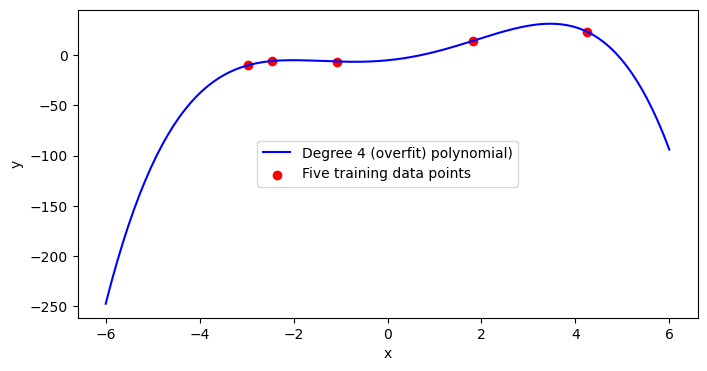

In [247]:
overfit_poly_coeffs = np.polyfit(x_train, y_train, 4)  
y_overfit_poly = np.polyval(overfit_poly_coeffs, x_many_pts)

# Plot the 5 training points, along with the overfit degree 4 polynomial. Observe that the polynomial passes through all points.

plt.figure(figsize=(8,4))
plt.plot(x_many_pts, y_overfit_poly, label='Degree 4 (overfit) polynomial)', color='blue')
plt.scatter(x_train, y_train, label='Five training data points', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='center')
plt.show()

Clearly, this does not generalise well (this is an understatement...). It has focused too much on the noise, resulting in a very inaccurate predictor.

We need to regularise.

### Regularisation

My understanding is that domain knowledge (or some knowledge of the source of the data) is needed in order to know which regulariser to choose.

In our case, for example, we could choose an $L$ norm on $\theta$, e.g., $\|\theta\|^2$, which punishes each coefficient equally. However, this is not going to encourage the production of a linear model. 

Alternatively, we could choose something like $\sum_{k=0}^7 |\theta_k|\cdot n^k$ for some large $n>1$, which *really* aims to punish coefficients associated with higher order terms. 

Let's go with something resembling the latter. We will punish $x^2$ and above terms with increasing severity (as looking at our noisy plotted points, we see that something linear would fit well, and so the model should aim to be basically linear, with the potential for some small higher order terms if it determines it is worth the punishment). 

Concretely, we aim to minimise the following function:

$$\frac{1}{5}\sum_{i=0}^4 \left(y_i - \sum_{k=0}^4 \theta_k x_i^k\right)^2 + \lambda \sum_{i=2}^4 \theta_i^2\cdot 2^i$$
where $\lambda$ is a hyperparameter (roughly, $\lambda$ is a measure of how much we want to enforce the regulariser term). Note that $(-)^2$ is preferred to $|-|$ for differentiability reasons.

If we make $\lambda$ too small, then the punishment won't be great enough, and so we will still get a high degree polynomial (e.g., in the extreme case of $\lambda = 0$, we will simply get our overfit degree 4 polynomial). 

The solution to choosing the right $\lambda$ (as mentioned at the beginning)? Choose a whole bunch of possible $\lambda$, use the training data to find parameters $\theta$ which minimise the loss function for each chosen lambda (we may denote these parameters by $\theta(\lambda)$, since they depend on $\lambda$), and then use the validation data to pick the best performing pair $(\lambda, \theta(\lambda))$.

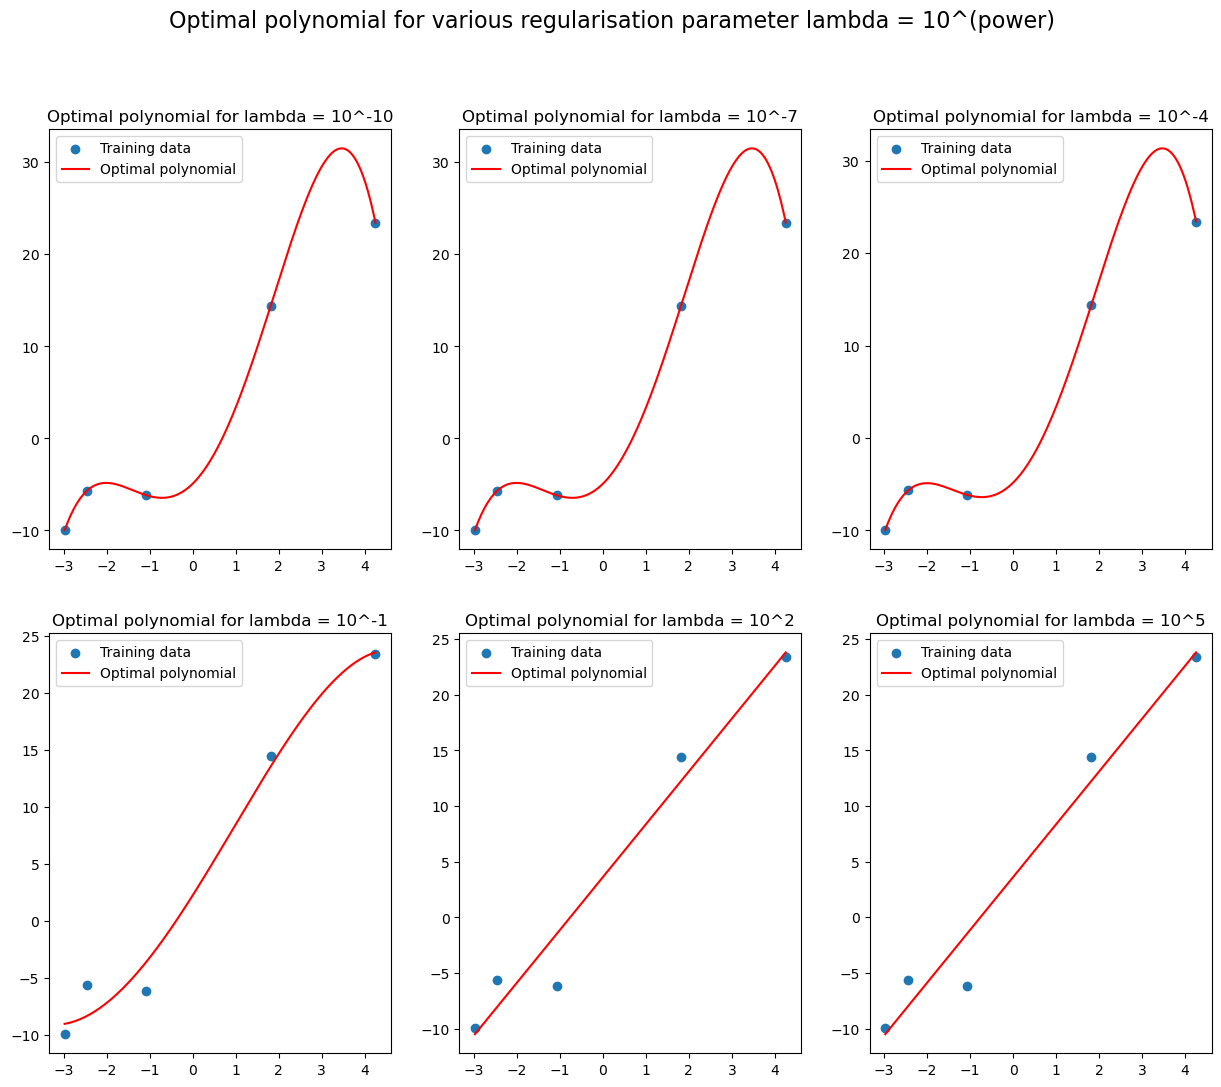

In [285]:
def loss_function(theta, lamb, xtrain, ytrain):
    '''
    The loss function is a function of theta = (theta_0,...,theta_4) and lambda
    We also pass the training data as arguments rather than referencing them globally (for robustness?)
    '''
    poly_evaluated_at_xtrain = np.polyval(theta[::-1], xtrain)
    LSL = 0.2*np.sum((ytrain - poly_evaluated_at_xtrain)**2)    
    regulariser = lamb * sum((theta[j])**2 * j**5 for j in range(2,len(theta)))
    return LSL + regulariser

#generate a bunch of options for lambda.
lambda_options_powers = np.arange(-10, 6) #lambdas will be 10^(power). We explicitly store powers for later use

best_theta_each_lambda = defaultdict(list)

# We will plot the optimal polynomial given by theta(lambda) for lambda = 10^(power) where power = -10,-7,-4,-1,2,5
# in a 2x3 grid. We set up the figure now.

plt.figure(figsize = (15,12))
plt.suptitle("Optimal polynomial for various regularisation parameter lambda = 10^(power)", fontsize=16)
plot_range = max(abs(x_train))+0.1
x_plot_values = np.linspace(min(x_train), max(x_train), 200)

for power in lambda_options_powers:
    lamb = 10.0**power

    initial_guess = np.zeros(5)
    result = minimize(lambda x: loss_function(x, lamb, x_train, y_train), initial_guess)
    
    best_theta_each_lambda["lambda_value"].append(lamb)
    best_theta_each_lambda["optimal_theta"].append(result.x)
    best_theta_each_lambda["function_loss"].append(result.fun)

    if power%3 == 2: #aka if power in [-10,-7,-4,-1,2,5]
        poly_values = np.polyval(result.x[::-1], x_plot_values)

        plt.subplot(2,3,int((power+13)/3)) # function taking (-10,-7,-4,-1,2,5) -> (1,2,3,4,5,6) is f(x) = (x+13)/3.
        plt.scatter(x_train, y_train, label='Training data')
        plt.plot(x_plot_values, poly_values, label='Optimal polynomial', color='red')
        plt.legend()
        plt.title(f"Optimal polynomial for lambda = 10^{power}")
plt.show()

In [289]:
#display the theta values, optimal theta and the value of the loss function in a table

df = pd.DataFrame(best_theta_each_lambda)
df['optimal_theta_rounded_for_display'] = df['optimal_theta'].apply(lambda lst: [round(x, 2) for x in lst])
print(df[['lambda_value','optimal_theta_rounded_for_display','function_loss']])

    lambda_value optimal_theta_rounded_for_display  function_loss
0   1.000000e-10  [-4.93, 4.57, 3.69, 0.23, -0.23]   5.080223e-08
1   1.000000e-09  [-4.93, 4.57, 3.69, 0.23, -0.23]   5.032366e-07
2   1.000000e-08  [-4.93, 4.57, 3.69, 0.23, -0.23]   5.027573e-06
3   1.000000e-07  [-4.93, 4.57, 3.69, 0.23, -0.23]   5.027027e-05
4   1.000000e-06  [-4.93, 4.57, 3.69, 0.23, -0.23]   5.026305e-04
5   1.000000e-05  [-4.92, 4.58, 3.68, 0.23, -0.23]   5.019564e-03
6   1.000000e-04   [-4.82, 4.6, 3.64, 0.22, -0.23]   4.953208e-02
7   1.000000e-03   [-3.97, 4.84, 3.23, 0.17, -0.2]   4.376920e-01
8   1.000000e-02  [-0.53, 5.77, 1.6, -0.03, -0.08]   2.064153e+00
9   1.000000e-01    [2.2, 5.97, 0.39, -0.13, -0.0]   3.986938e+00
10  1.000000e+00     [3.29, 5.1, 0.07, -0.04, 0.0]   5.895562e+00
11  1.000000e+01     [3.57, 4.79, 0.01, -0.0, 0.0]   6.490343e+00
12  1.000000e+02      [3.62, 4.75, 0.0, -0.0, 0.0]   6.563732e+00
13  1.000000e+03      [3.62, 4.75, 0.0, -0.0, 0.0]   6.571264e+00
14  1.0000

From the above plots, we can see that for a  very small $\lambda$ (say, $\lambda = 10^{-10}$), the regulariser is not punishing enough, and so the model is still happy to take a degree $4$ polynomial. 

As $\lambda$ gets very large, we force linearisation of the polynomial more and more strongly.

Let us now concretely check which $\lambda$ value is best, by testing the parameters $\theta(\lambda)$ on the validation data.

In [235]:
def validation_loss_function(theta, xvalidate, yvalidate):
    '''
    The loss function we want to use on the validation data is just the loss
    function above with no regulariser, i.e., lambda = 0
    '''
    poly_evaluated_at_xvalidate = np.polyval(theta[::-1], xvalidate)
    return 0.2*np.sum((yvalidate - poly_evaluated_at_xvalidate)**2) 

best_lamb = None
best_theta = None
min_loss_on_validation = np.inf

losses_on_validation = defaultdict(list)

for _, row in df.iterrows():
    lamb = row['lambda_value']
    theta = row['optimal_theta']
    loss_func_value = validation_loss_function(theta, x_validate, y_validate)
    if loss_func_value < min_loss_on_validation:
        min_loss_on_validation = loss_func_value
        best_lamb = lamb
        best_theta = theta
    losses_on_validation['lambda'].append(lamb)
    losses_on_validation['theta'].append(theta)
    losses_on_validation['validation_loss_value'].append(loss_func_value)

df_loss_on_val = pd.DataFrame(losses_on_validation)
df_loss_on_val['theta_rounded'] = df_loss_on_val['theta'].apply(lambda lst: [round(x, 2) for x in lst])
print(df_loss_on_val[['lambda','theta_rounded','validation_loss_value']])

print(f"\nThe best lambda is {best_lamb}\n")
print(f"The corresponding theta values are\n {best_theta}\n")
printed_best_poly = ''.join([str(round(coeff,3))+str(xpower)+" + " 
                             for (coeff,xpower) in zip(best_theta,['','x','x^2','x^3','x^4'])])[:-3]
print(f"As a polynomial (coeffs rounded), this is\n{printed_best_poly}\n")
print(f"The loss on the validation data is {min_loss_on_validation}\n")

          lambda                     theta_rounded  validation_loss_value
0   1.000000e-10  [-4.93, 4.57, 3.69, 0.23, -0.23]              41.684606
1   1.000000e-09  [-4.93, 4.57, 3.69, 0.23, -0.23]              41.684600
2   1.000000e-08  [-4.93, 4.57, 3.69, 0.23, -0.23]              41.684538
3   1.000000e-07  [-4.93, 4.57, 3.69, 0.23, -0.23]              41.683919
4   1.000000e-06  [-4.93, 4.57, 3.69, 0.23, -0.23]              41.677726
5   1.000000e-05  [-4.92, 4.58, 3.68, 0.23, -0.23]              41.615925
6   1.000000e-04   [-4.82, 4.6, 3.64, 0.22, -0.23]              41.010592
7   1.000000e-03   [-3.97, 4.84, 3.23, 0.17, -0.2]              36.014926
8   1.000000e-02  [-0.53, 5.77, 1.6, -0.03, -0.08]              20.547699
9   1.000000e-01    [2.2, 5.97, 0.39, -0.13, -0.0]              11.761906
10  1.000000e+00     [3.29, 5.1, 0.07, -0.04, 0.0]               7.220154
11  1.000000e+01     [3.57, 4.79, 0.01, -0.0, 0.0]               6.414666
12  1.000000e+02      [3.62, 4.75, 0.0

Observe that for $\lambda \approx 0$, the model performs very poorly on the validation data, despite performing essentially perfectly on the training data.

Finally (just for interest), let's compare the loss of the best performing $(\lambda,\theta(\lambda))$ pair to the loss of the original (unnoisy) polynomial $5x + 3$. 

Note that the original polynomial will, of course, have a non-zero loss (due to the noise). Note also that if simulated many times (i.e., if the notebook is run many times), the original may sometimes be better than our found optimal polynomial, but this is only because the $\lambda$ values we tested with are discrete (i.e., $\lambda \in \{\ldots, 0.01, 0.1, 1, 10, 100,\ldots\}$). The true best $\lambda \in \mathbb{R}$ value almost certainly lies in between two of these points.

Let's also plot the data generating polynomial (i.e., $5x+3$), our found optimal polynomial, and our $10$ data points.

The loss on the validation data of the function 5x + 3 is 19.972469742042456

----------

Plot of the data-generating polynomial 5x + 3, our optimal polynomial, and the data points



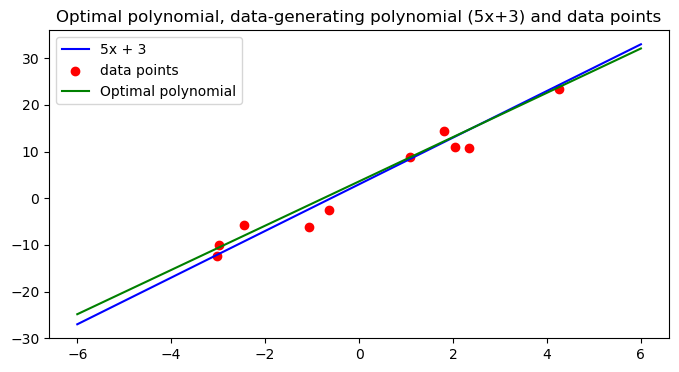

In [300]:
print(f"The loss on the validation data of the function 5x + 3 is {validation_loss_function([5,3,0,0,0], x_validate, y_validate)}\n")

print(f"{'-'*10}\n\nPlot of the data-generating polynomial 5x + 3, our optimal polynomial, and the data points\n")

plt.figure(figsize=(8,4))
plt.plot(x_many_pts, y_no_noise, label='5x + 3', color='blue')
plt.scatter(x_array, y_values, label='data points', color='red')
best_poly_values = np.polyval(best_theta[::-1], x_many_pts)
plt.plot(x_many_pts, best_poly_values, label='Optimal polynomial', color='green')
plt.legend()
plt.title(f"Optimal polynomial, data-generating polynomial (5x+3) and data points")
plt.show()